##### ================= STAGE 05 DEEP INSIGHT ANALYSIS AND RESEARCH FINDINGS =============== ######

We want something closer to what customer experiences are such as daily usage, outages, complaints. Here, each row approximate one customer-daily experience.
We would load the dataset from engineered_data_daily since that is the aggregated dataset for daily expereinces.

One key strong insight is to focus on complaints, outages, and tariff type and aim for a board‑level insight by answering the question: `variable‑tariff customers in high‑outage regions have significantly higher complaint rates than fixed‑tariff customers, especially where smart meters are deployed.`

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
# LOAD DATA FROM DATA/CLEANED FOLDER
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(BASE_DIR, "data", "engineered", "energy_engineered_daily_aggregated_data.csv")
daily_df = pd.read_csv(data_path)
daily_df.head()

,customer_id,region,tariff_plan,is_smart_meter,date,day_name,daily_kwh,daily_outage_minutes,daily_bill_eur,any_complaint,high_outage_day
0,201,East,fixed,1,2026-01-01,Thursday,40.674543,15,7.321418,0,1
1,201,East,fixed,1,2026-01-02,Friday,29.456769,16,5.302218,0,1
2,201,East,fixed,1,2026-01-03,Saturday,32.690122,15,5.884222,1,1
3,201,East,fixed,1,2026-01-04,Sunday,34.040236,13,6.127243,1,0
4,201,East,fixed,1,2026-01-05,Monday,31.587888,17,5.685820,1,1


###### `ANALYSIS OF THE DATASET`

##### `DISTRIBUTION PLOTS`

<Axes: xlabel='day_name'>

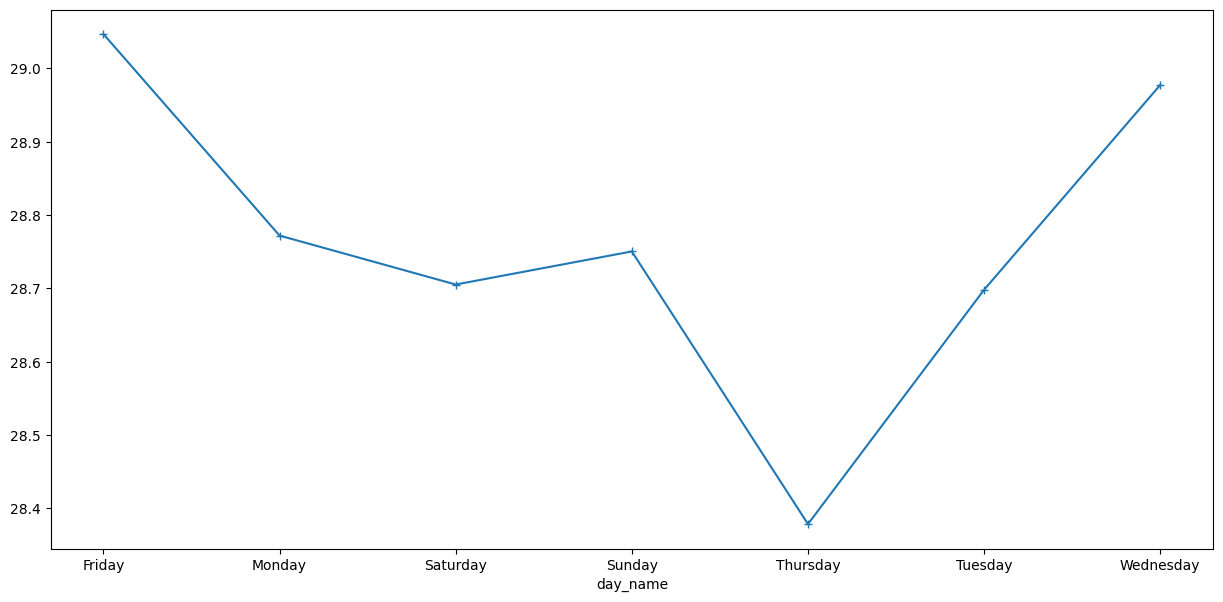

In [3]:
# PLOT AVERAGE DAILY KWH BY DAY OF WEEK USING LINE PLOT
daily_df.groupby("day_name")["daily_kwh"].mean().plot(kind="line", figsize=(15, 7), marker='+')

<Axes: >

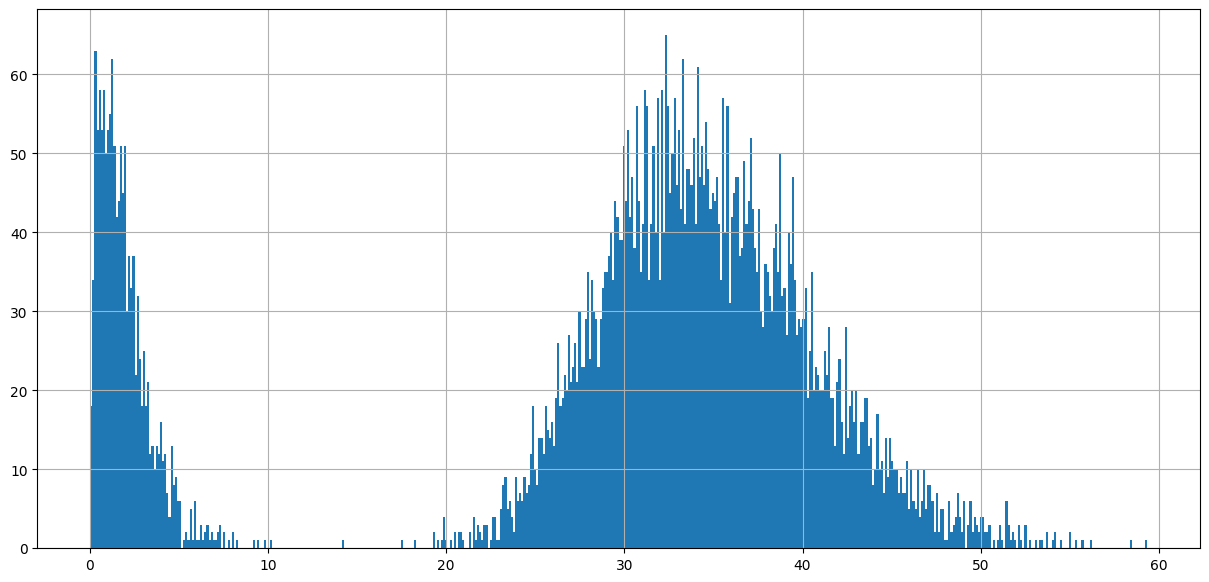

In [4]:
# PLOT DAILY_KWH DISTRIBUTION USING HISTOGRAM
daily_df["daily_kwh"].hist(bins=500, figsize=(15, 7))

<Axes: xlabel='day_name'>

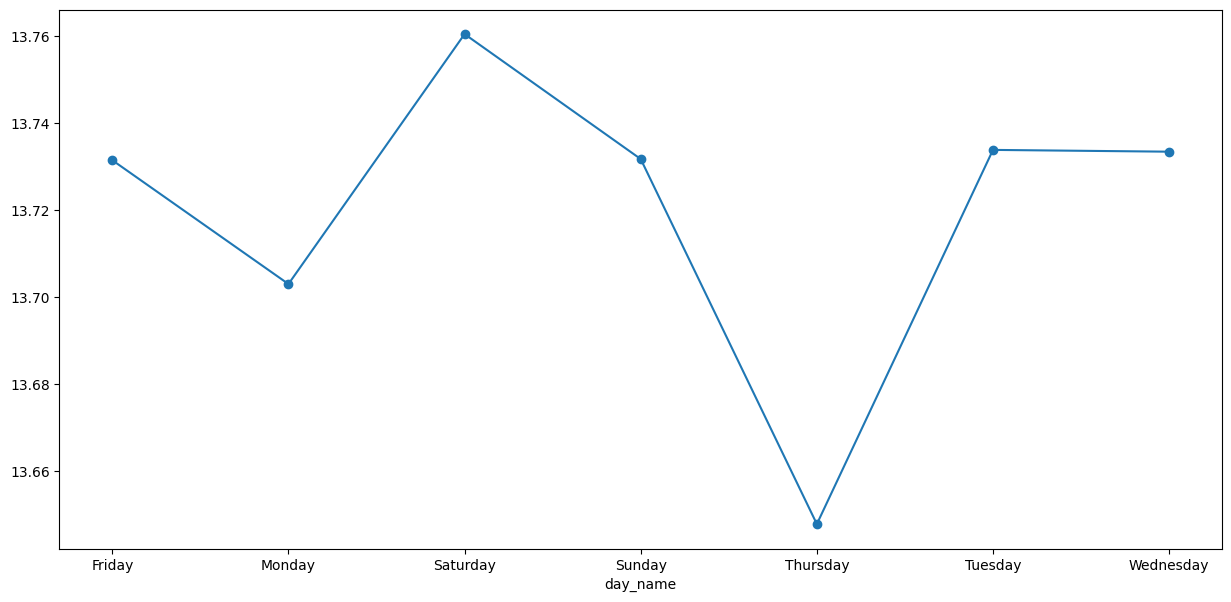

In [5]:
daily_df.groupby("day_name")["daily_outage_minutes"].mean().plot(kind="line", figsize=(15, 7), marker='o')

<Axes: xlabel='day_name'>

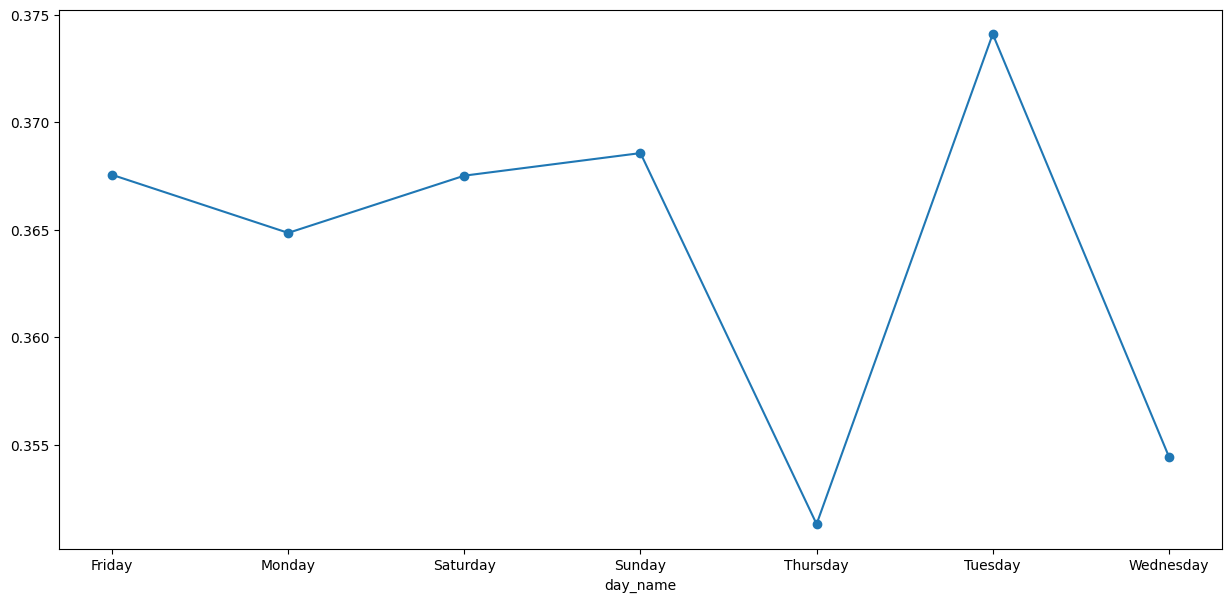

In [6]:
daily_df.groupby("day_name")["high_outage_day"].mean().plot(kind="line", figsize=(15, 7), marker='o')

<Axes: xlabel='day_name'>

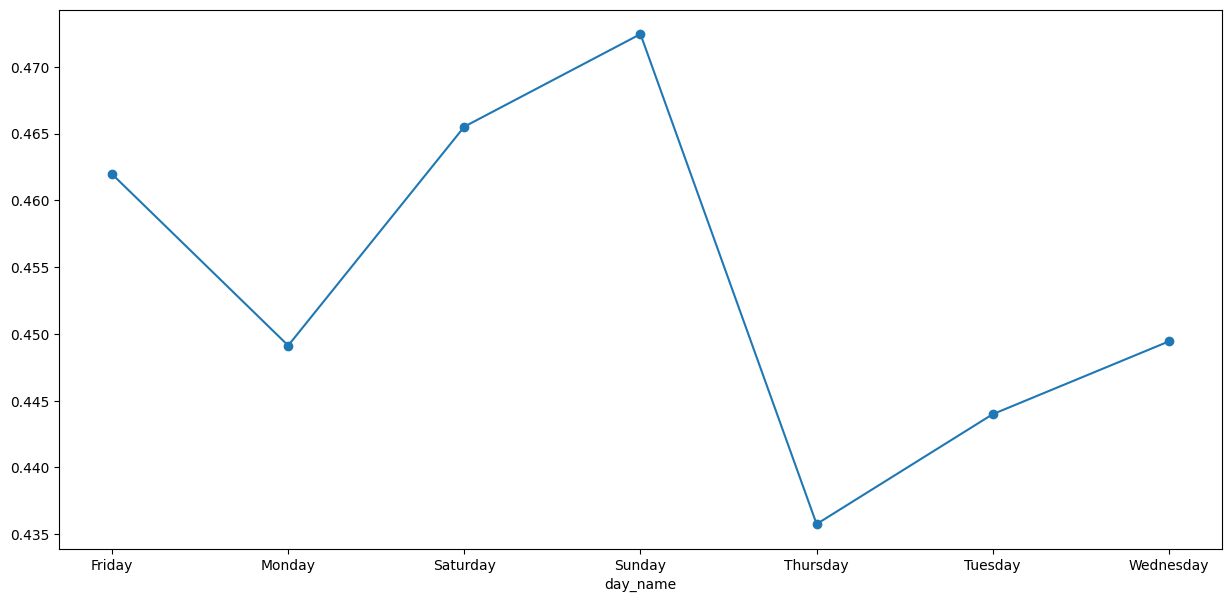

In [7]:
daily_df.groupby("day_name")["any_complaint"].mean().plot(kind="line", figsize=(15, 7), marker='o')

###### `DEFINE THE HIGH OUTAGE VS LOW OUTAGE THRESHOLD`

In [19]:
# DAILY HIGH OUTAGE
daily_df[daily_df["daily_outage_minutes"] > 15]

,customer_id,region,tariff_plan,is_smart_meter,date,day_name,daily_kwh,daily_outage_minutes,daily_bill_eur,any_complaint,high_outage_day,low_outage_day
1,201,East,fixed,1,2026-01-02,Friday,29.456769,16,5.302218,0,0,1
4,201,East,fixed,1,2026-01-05,Monday,31.587888,17,5.685820,1,0,1
5,201,East,fixed,1,2026-01-06,Tuesday,33.245877,16,6.766270,0,0,1
8,201,East,fixed,1,2026-01-09,Friday,36.101545,17,6.998212,0,0,1
9,201,East,fixed,1,2026-01-10,Saturday,34.378219,17,6.188079,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
6952,294,West,fixed,1,2026-02-21,Saturday,41.678684,17,8.693579,1,0,1
6958,294,West,fixed,1,2026-02-27,Friday,32.353965,19,5.940188,1,0,1
7104,297,West,variable,1,2026-01-07,Wednesday,34.352744,18,5.606368,1,0,1
7118,297,West,variable,1,2026-01-21,Wednesday,27.983698,16,4.788713,0,0,1


In [22]:
len(daily_df[daily_df["daily_outage_minutes"] > 15])

2325

In [23]:

daily_df["high_outage_day"] = (daily_df["daily_outage_minutes"] > 15).astype(int)
daily_df.head()

,customer_id,region,tariff_plan,is_smart_meter,date,day_name,daily_kwh,daily_outage_minutes,daily_bill_eur,any_complaint,high_outage_day,low_outage_day
0,201,East,fixed,1,2026-01-01,Thursday,40.674543,15,7.321418,0,0,1
1,201,East,fixed,1,2026-01-02,Friday,29.456769,16,5.302218,0,1,1
2,201,East,fixed,1,2026-01-03,Saturday,32.690122,15,5.884222,1,0,1
3,201,East,fixed,1,2026-01-04,Sunday,34.040236,13,6.127243,1,0,1
4,201,East,fixed,1,2026-01-05,Monday,31.587888,17,5.685820,1,1,1


In [24]:
# DAILY LOW OUTAGE
daily_df[daily_df["daily_outage_minutes"] <= 15]

,customer_id,region,tariff_plan,is_smart_meter,date,day_name,daily_kwh,daily_outage_minutes,daily_bill_eur,any_complaint,high_outage_day,low_outage_day
0,201,East,fixed,1,2026-01-01,Thursday,40.674543,15,7.321418,0,0,1
2,201,East,fixed,1,2026-01-03,Saturday,32.690122,15,5.884222,1,0,1
3,201,East,fixed,1,2026-01-04,Sunday,34.040236,13,6.127243,1,0,1
6,201,East,fixed,1,2026-01-07,Wednesday,37.446504,14,6.740371,1,0,1
7,201,East,fixed,1,2026-01-08,Thursday,37.194330,14,6.694979,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7333,300,South,fixed,0,2026-02-25,Wednesday,37.621770,11,6.433323,1,0,1
7334,300,South,fixed,0,2026-02-26,Thursday,39.067503,10,6.680543,0,0,1
7335,300,South,fixed,0,2026-02-27,Friday,26.174300,9,4.475805,1,0,1
7336,300,South,fixed,0,2026-02-28,Saturday,29.142297,10,5.154182,1,0,1


In [25]:
len(daily_df[daily_df["daily_outage_minutes"] <= 15])

5013

In [26]:
daily_df["low_outage_day"] = (daily_df["daily_outage_minutes"] <= 15).astype(int)
daily_df.head()

,customer_id,region,tariff_plan,is_smart_meter,date,day_name,daily_kwh,daily_outage_minutes,daily_bill_eur,any_complaint,high_outage_day,low_outage_day
0,201,East,fixed,1,2026-01-01,Thursday,40.674543,15,7.321418,0,0,1
1,201,East,fixed,1,2026-01-02,Friday,29.456769,16,5.302218,0,1,0
2,201,East,fixed,1,2026-01-03,Saturday,32.690122,15,5.884222,1,0,1
3,201,East,fixed,1,2026-01-04,Sunday,34.040236,13,6.127243,1,0,1
4,201,East,fixed,1,2026-01-05,Monday,31.587888,17,5.685820,1,1,0


##### `COMPLAINT RATE BY TARIFF AND OUTAGE LEVEL`

In [27]:
complaint_summary = (
    daily_df
    .groupby(['region', 'tariff_plan', 'high_outage_day'])
    .agg(
        no_of_days=('customer_id', 'count'),
        complaint_days=('any_complaint', 'sum')
    )
    .reset_index()
)

complaint_summary['complaint_rate'] = round(
    complaint_summary['complaint_days'] / complaint_summary['no_of_days'],
    2
)

complaint_summary.sort_values('complaint_rate', ascending=True)


,region,tariff_plan,high_outage_day,no_of_days,complaint_days,complaint_rate
7,South,fixed,1,135,6,0.04
9,South,variable,1,114,8,0.07
6,South,fixed,0,2647,788,0.30
10,West,fixed,0,670,262,0.39
1,East,fixed,1,542,242,0.45
11,West,fixed,1,50,23,0.46
0,East,fixed,0,238,109,0.46
8,South,variable,0,1022,503,0.49
13,West,variable,1,21,13,0.62
4,North,fixed,1,720,466,0.65


`We can see that:`

- *Higher complaint rates occur in the `North`*

- *Higher complaint rates for `variable tariff` and `fixed tariff`*

- *Higher complaint rates on `high‑outage days`*

###### `FOCUS ON ONE NARRATIVE SLICE`

Further investigate the `North` region to make the story sharp.

In [32]:
north = complaint_summary[complaint_summary['region'] == 'North']

north_pivot = north.pivot_table(
    index='tariff_plan',
    columns='high_outage_day',
    values='complaint_rate'
)

# north_pivot.columns = ['low_outage_complaint_rate', 'high_outage_complaint_rate']
# north_pivot['complaint_rate_diff'] = north_pivot['high_outage_complaint_rate'] - north_pivot['low_outage_complaint_rate']
# north_pivot.sort_values('complaint_rate_diff', ascending=False)

In [39]:
north_pivot.columns = ['high_outage_complaint_rate']
north_pivot.sort_values('high_outage_complaint_rate', ascending=False)

,high_outage_complaint_rate
tariff_plan,
variable,0.84
fixed,0.65


Interpretation:

On high‑outage days in the North, the fixed-tarfiff and variable‑tariff customers complained for high outage are respectively 65% and 84% of customer‑days.

That is, the customrs in this region do not enjoy the energy services they subscribed for despite their consistence efforts in putting their complaints forward.

In the North, `both fixed and variable tariff is fragile under reliability issues and customers perceive this as unfair or unpredictable when outages occur.`

In [ ]:
south = complaint_summary[complaint_summary['region'] == 'South']

south_pivot = south.pivot_table(
    index='tariff_plan',
    columns='high_outage_day',
    values='complaint_rate'
)


south_pivot.columns = ['low_outage_complaint_rate', 'high_outage_complaint_rate']
south_pivot

,low_outage_complaint_rate,high_outage_complaint_rate
tariff_plan,,
fixed,0.30,0.04
variable,0.49,0.07


In [41]:
west = complaint_summary[complaint_summary['region'] == 'West']

west_pivot = west.pivot_table(
    index='tariff_plan',
    columns='high_outage_day',
    values='complaint_rate'
)

# west_pivot.columns = ['outage_complaint_rate']
# west_pivot.sort_values('outage_complaint_rate', ascending=False)
west_pivot.columns = ['low_outage_complaint_rate', 'high_outage_complaint_rate']
west_pivot

,low_outage_complaint_rate,high_outage_complaint_rate
tariff_plan,,
fixed,0.39,0.46
variable,0.72,0.62


In [42]:
east = complaint_summary[complaint_summary['region'] == 'East']

east_pivot = east.pivot_table(
    index='tariff_plan',
    columns='high_outage_day',
    values='complaint_rate'
)

# east_pivot.columns = ['outage_complaint_rate']
# east_pivot.sort_values('outage_complaint_rate', ascending=False)
east_pivot.columns = ['low_outage_complaint_rate', 'high_outage_complaint_rate']
east_pivot

,low_outage_complaint_rate,high_outage_complaint_rate
tariff_plan,,
fixed,0.46,0.45
variable,0.72,0.74
